##  Session 4 — Supervised Learning II & Unsupervised Learning
## Module 6 — Regression

**Learning Objective**: Understand how to build models that predict continuous numerical values.

📘 **Concepts: Predicting Continuous Values with Regression**

While classification models predict categories, **regression models** predict continuous numerical values. This is essential when your target variable isn't a discrete class but a quantity, such as protein concentration, gene expression level, patient age, or drug efficacy.

### Linear Regression

**Linear Regression** is one of the simplest and most fundamental regression algorithms. It assumes a linear relationship between the input features (independent variables) and the target variable (dependent variable).

*   **Simple Linear Regression**: Involves a single input feature. It tries to find the best-fitting straight line through the data points that minimizes the sum of the squared differences between the predicted values and the actual values (this is called the **Ordinary Least Squares, OLS** method).
    The equation is typically $y = mx + b$ or $y = \beta_0 + \beta_1 x_1$.

*   **Multiple Linear Regression**: Involves two or more input features. It extends the concept of simple linear regression to multiple dimensions, finding a hyperplane that best fits the data. The equation becomes $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$.

### Model Evaluation Metrics for Regression

Unlike classification, where we use accuracy, regression models are evaluated based on how close their predictions are to the actual values.

*   **Mean Absolute Error (MAE)**: The average of the absolute differences between predictions and actual values. It's robust to outliers.
    $MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$

*   **Mean Squared Error (MSE)**: The average of the squared differences between predictions and actual values. It penalizes larger errors more heavily, making it sensitive to outliers.
    $MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

*   **Root Mean Squared Error (RMSE)**: The square root of MSE. It's in the same units as the target variable, making it more interpretable than MSE.
    $RMSE = \sqrt{MSE}$

*   **R-squared (Coefficient of Determination)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. It ranges from 0 to 1, where 1 means the model perfectly explains the variance. A higher R-squared indicates a better fit.
    $R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$, where $SS_{res}$ is the sum of squares of residuals and $SS_{tot}$ is the total sum of squares.

### Assumptions of Linear Regression

Linear regression makes several assumptions about the data. While models can still be useful if these are violated, interpreting coefficients or relying on p-values becomes problematic.

1.  **Linearity**: There is a linear relationship between features and the target.
2.  **Independence**: Observations are independent of each other.
3.  **Homoscedasticity**: The variance of the residuals (errors) is constant across all levels of the independent variables.
4.  **Normality**: The residuals are normally distributed.

### Dataset: Diabetes Dataset

For this module, we will use the scikit-learn built-in **Diabetes dataset**. This dataset consists of 442 patients, with 10 physiological features (e.g., age, sex, body mass index, average blood pressure, and six blood serum measurements) and a quantitative measure of disease progression one year after baseline. This is a classic regression problem where we aim to predict a continuous outcome (disease progression) from patient features. It's preprocessed and clean, making it suitable for a direct application of regression.

**Features**: 10 features (all numeric, normalized to have 0 mean and unit variance)
**Target**: Quantitative measure of disease progression (a continuous numerical value)

First 5 rows of Diabetes features (normalized):
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  

First 5 target values (disease progression):
[151.  75. 141. 206. 135.]

Shape of X_train: (353, 10)
Shape of X_test: (89, 10)

Model Coefficients: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
Model

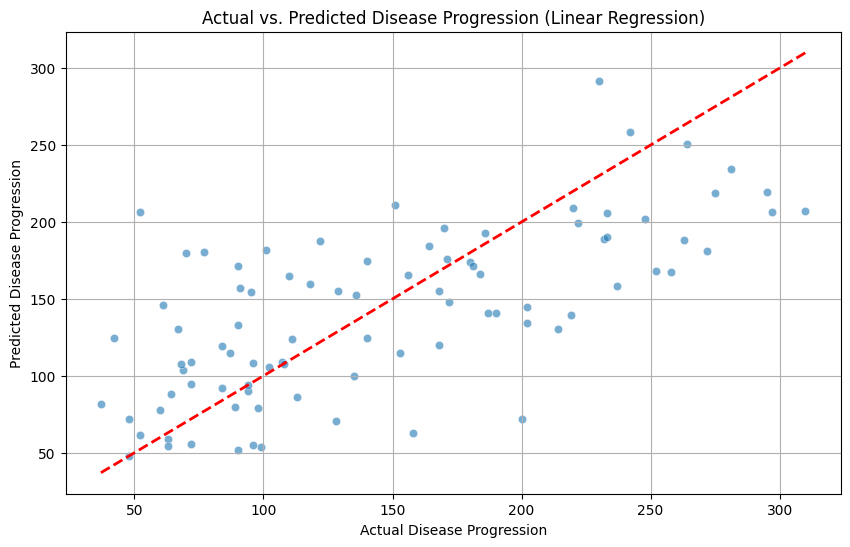

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Diabetes dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

# Create a DataFrame for features for easier inspection
X_df = pd.DataFrame(X, columns=diabetes.feature_names)

print("First 5 rows of Diabetes features (normalized):")
print(X_df.head())

print("\nFirst 5 target values (disease progression):")
print(y[:5])

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

# Initialize and train a Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Coefficients: {linear_model.coef_}")
print(f"Model Intercept: {linear_model.intercept_:.2f}")
print(f"\nMean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Plotting actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Disease Progression')
plt.ylabel('Predicted Disease Progression')
plt.title('Actual vs. Predicted Disease Progression (Linear Regression)')
plt.grid(True)
plt.show()


🎯 **Predict→Run→Interpret: Feature Importance**

Linear Regression models provide coefficients for each feature, indicating their weight or importance in the prediction. A larger absolute coefficient value means that feature has a stronger influence on the target variable. Before looking at the `linear_model.coef_` values (which were printed above):

*   **Predict**: Based on common biological understanding, which physiological features (e.g., BMI, blood pressure, age, sex, etc.) do you think would have the strongest (largest absolute) coefficients in predicting diabetes disease progression?

*Your Prediction:*

Now, let's interpret the coefficients from the `linear_model.coef_` output. Which features indeed have the largest absolute coefficients? Does this align with your biological intuition? Why or why not?

**Hint: The feature names are available in `diabetes.feature_names` in the same order as the coefficients.**

*Your Interpretation:*

✅ **Checkpoint: Model Limitations**

Given the R-squared value and the scatter plot of actual vs. predicted values, what are some potential limitations of this simple Linear Regression model for predicting diabetes progression? In a real-world clinical setting, would you solely rely on this model for making critical patient decisions? Why or why not?

*Your Answer Here:*

## Review & Practice: Module 6 — Regression

### Summary of Module 6 Code

Module 6 introduced **Regression** models, which are used to predict continuous numerical values. We specifically focused on **Linear Regression** and its evaluation metrics, using the Diabetes dataset.

Key steps and concepts covered included:

1.  **Loading and Initial Inspection of Regression Data**: We loaded the `load_diabetes` dataset, which includes physiological features and a quantitative measure of disease progression. We inspected its structure using `df.head()`.
    ```python
    from sklearn.datasets import load_diabetes
    import pandas as pd

    diabetes = load_diabetes()
    X, y = diabetes.data, diabetes.target
    X_df = pd.DataFrame(X, columns=diabetes.feature_names)
    print(X_df.head())
    ```

2.  **Train/Test Split**: As always, we split the data into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`) to ensure proper model evaluation on unseen data.
    ```python
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    ```

3.  **Linear Regression Model Training**: We initialized and trained a `LinearRegression` model on the training data.
    ```python
    from sklearn.linear_model import LinearRegression

    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    y_pred = linear_model.predict(X_test)
    ```

4.  **Regression Model Evaluation**: We evaluated the model's performance using standard regression metrics:
    *   **Mean Squared Error (MSE)**: Average of the squared differences between actual and predicted values.
    *   **Root Mean Squared Error (RMSE)**: Square root of MSE, providing error in the same units as the target.
    *   **Mean Absolute Error (MAE)**: Average of the absolute differences, robust to outliers.
    *   **R-squared (R2)**: Proportion of variance in the dependent variable predictable from the independent variables.
    
    We used `sklearn.metrics` functions for these calculations.
    ```python
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
    import numpy as np

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2: {r2:.2f}")
    ```

5.  **Visualizing Actual vs. Predicted Values**: A scatter plot comparing `y_test` and `y_pred` helped visualize the model's fit and identify any patterns in its errors.
    ```python
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title('Actual vs. Predicted Values (Linear Regression)')
    plt.show()
    ```

Module 6 provided a practical foundation for building and evaluating models that predict continuous outcomes, a common task in various biological applications.

### Practice Test: Module 6

**Task**: Let's apply regression to a hypothetical **CO2-related scenario**. Imagine you have collected data on `temperature` and corresponding `CO2_concentration` measurements. Your goal is to build a linear regression model to predict `CO2_concentration` based on `temperature`.

Your task is to:

1.  **Generate Synthetic Data**: Create two NumPy arrays:
    *   `temperature`: 100 random values between 15 and 30 (representing Celsius).
    *   `co2_concentration`: Calculate `co2_concentration = 200 + 5 * temperature + noise`, where `noise` is random values (e.g., `np.random.normal(0, 10, 100)`).
2.  **Create a Pandas DataFrame**: Combine `temperature` and `co2_concentration` into a DataFrame.
3.  **Split Data**: Split your DataFrame into training (80%) and testing (20%) sets for both features (`X_train_co2`, `X_test_co2`) and target (`y_train_co2`, `y_test_co2`). Remember that `temperature` needs to be reshaped for `sklearn`.
4.  **Train Linear Regression Model**: Initialize and fit a `LinearRegression` model using the training data.
5.  **Make Predictions**: Predict `co2_concentration` values for the test set.
6.  **Evaluate Model**: Calculate and print the `MAE`, `MSE`, `RMSE`, and `R-squared` for your model.
7.  **Visualize**: Create a scatter plot showing `Actual CO2 Concentration` vs. `Predicted CO2 Concentration` on the test set, similar to the one in the main module.

First 5 rows of the synthetic CO2 data:
   temperature  co2_concentration
0    20.618102         303.960980
1    29.260715         343.313499
2    25.979909         330.817153
3    23.979877         300.023697
4    17.340280         284.504679

Shape of X_train_co2: (80, 1)
Shape of X_test_co2: (20, 1)

Model Coefficients (CO2): 4.73
Model Intercept (CO2): 205.44

Mean Squared Error (MSE) CO2: 65.37
Root Mean Squared Error (RMSE) CO2: 8.09
Mean Absolute Error (MAE) CO2: 5.91
R-squared (R2) CO2: 0.87


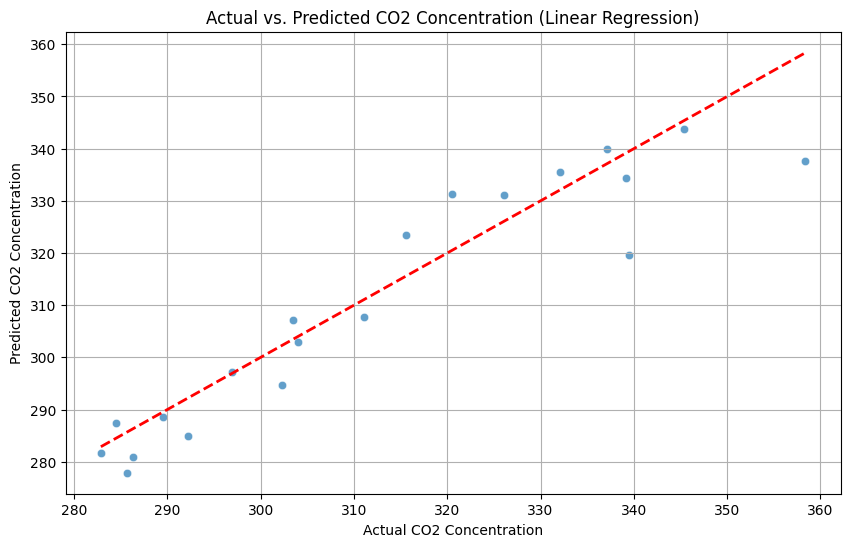

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate Synthetic Data
np.random.seed(42) # for reproducibility
temperature = np.random.uniform(15, 30, 100)
noise = np.random.normal(0, 10, 100)
co2_concentration = 200 + 5 * temperature + noise

# 2. Create a Pandas DataFrame
co2_df = pd.DataFrame({'temperature': temperature, 'co2_concentration': co2_concentration})
print("First 5 rows of the synthetic CO2 data:")
print(co2_df.head())

# Separate features (X) and target (y)
X_co2 = co2_df[['temperature']]
y_co2 = co2_df['co2_concentration']

# 3. Split Data
X_train_co2, X_test_co2, y_train_co2, y_test_co2 = train_test_split(X_co2, y_co2, test_size=0.2, random_state=42)

print(f"\nShape of X_train_co2: {X_train_co2.shape}")
print(f"Shape of X_test_co2: {X_test_co2.shape}")

# 4. Train Linear Regression Model
linear_model_co2 = LinearRegression()
linear_model_co2.fit(X_train_co2, y_train_co2)

# 5. Make Predictions
y_pred_co2 = linear_model_co2.predict(X_test_co2)

# 6. Evaluate Model
mse_co2 = mean_squared_error(y_test_co2, y_pred_co2)
rmse_co2 = np.sqrt(mse_co2)
mae_co2 = mean_absolute_error(y_test_co2, y_pred_co2)
r2_co2 = r2_score(y_test_co2, y_pred_co2)

print(f"\nModel Coefficients (CO2): {linear_model_co2.coef_[0]:.2f}")
print(f"Model Intercept (CO2): {linear_model_co2.intercept_:.2f}")
print(f"\nMean Squared Error (MSE) CO2: {mse_co2:.2f}")
print(f"Root Mean Squared Error (RMSE) CO2: {rmse_co2:.2f}")
print(f"Mean Absolute Error (MAE) CO2: {mae_co2:.2f}")
print(f"R-squared (R2) CO2: {r2_co2:.2f}")

# 7. Visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_co2, y=y_pred_co2, alpha=0.7)
plt.plot([y_test_co2.min(), y_test_co2.max()], [y_test_co2.min(), y_test_co2.max()], 'r--', lw=2)
plt.xlabel('Actual CO2 Concentration')
plt.ylabel('Predicted CO2 Concentration')
plt.title('Actual vs. Predicted CO2 Concentration (Linear Regression)')
plt.grid(True)
plt.show()

---

---

## Module 7 — Unsupervised Learning: Clustering

**Learning Objective**: Discover hidden structures and groupings in data using clustering algorithms.

📘 **Concepts: Finding Groups in Data with Clustering**

Unlike supervised learning, where we have labeled data to train our models, **unsupervised learning** deals with unlabeled data. One of the most common unsupervised tasks is **clustering**, which aims to group similar data points together based on their intrinsic properties. Imagine you have a collection of biological samples, but you don't know if there are distinct types among them. Clustering algorithms can help you discover these natural groupings.

### K-Means Clustering

**K-Means** is a popular and relatively simple clustering algorithm. Its goal is to partition `n` observations into `k` clusters, where each observation belongs to the cluster with the nearest mean (centroid).

Here's how K-Means generally works:

1.  **Initialization**: Randomly select `k` data points from the dataset as initial cluster centroids.
2.  **Assignment Step**: Assign each data point to the nearest centroid. The 'nearest' is typically determined by Euclidean distance.
3.  **Update Step**: Recalculate the centroids as the mean of all data points assigned to that cluster.
4.  **Iteration**: Repeat steps 2 and 3 until the centroids no longer change significantly, or a maximum number of iterations is reached.

### Key Concepts in K-Means:

*   **Centroid**: The geometric center of a cluster (the mean of all points within that cluster).
*   **Inertia (or Sum of Squared Distances)**: A measure of how internally coherent clusters are. It's the sum of squared distances of samples to their closest cluster center. Lower inertia is generally better, but it decreases with more clusters. This is where the elbow method comes in.
*   **Elbow Method**: A heuristic used to determine the optimal number of clusters (`k`). You plot the inertia (or distortion) as a function of the number of clusters (`k`). The 'elbow' point on the curve, where the rate of decrease in inertia sharply changes, is often considered a good estimate for `k`.

🔬 **Why this matters in biology**

Clustering is an invaluable tool in bioinformatics and computational biology for discovering hidden patterns and structures within complex biological data, where explicit labels are often unavailable or difficult to obtain:

*   **Cell Type Identification**: In single-cell RNA sequencing, clustering helps identify distinct cell populations (e.g., T-cells, B-cells, macrophages) within a heterogeneous tissue sample, even when prior knowledge of these cell types is limited.
*   **Disease Subtype Discovery**: Grouping patients based on their molecular profiles (e.g., gene expression, proteomic data) can reveal novel disease subtypes that may respond differently to treatments, leading to personalized medicine approaches.
*   **Gene Co-expression Analysis**: Identifying groups of genes that are co-expressed across various conditions or samples can suggest their involvement in common biological pathways or regulatory networks.
*   **Microbial Community Profiling**: Analyzing metagenomic data to cluster microbial species or operational taxonomic units (OTUs) helps characterize the composition and diversity of microbial communities in different environments (e.g., gut microbiome, soil samples).
*   **Structural Biology**: Clustering conformations of proteins or other biomolecules from molecular dynamics simulations can help understand their dynamic behavior and functional states.

By revealing natural groupings, clustering provides hypotheses about underlying biological mechanisms or classifications, guiding further experimental validation.

### Dataset: Iris Flowers (revisited for Clustering)

For this module, we will revisit the **Iris dataset**. While we previously used its `species` labels for classification, this time, we will *ignore* those labels and use clustering to see if the algorithm can autonomously discover the natural groupings (which we know to be the three species). This provides a great way to visually assess the effectiveness of the clustering algorithm.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the Iris dataset
iris = load_iris()
X = iris.data  # We will use all features for clustering

# Scale the features (important for distance-based algorithms like KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("First 5 rows of scaled Iris features:")
print(pd.DataFrame(X_scaled, columns=iris.feature_names).head())

# --- 1. Determine optimal K using the Elbow Method ---

inertia = []
# Try K from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# --- 2. Apply K-Means with the chosen K (e.g., K=3 for Iris) ---
# From the elbow plot, 3 is usually a good choice for the Iris dataset.
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(X_scaled)

# Add cluster assignments to a DataFrame for visualization
iris_df_clustered = pd.DataFrame(X_scaled, columns=iris.feature_names)
iris_df_clustered['cluster'] = clusters
iris_df_clustered['actual_species'] = iris.target_names[iris.target] # For comparison

print(f"\nFirst 5 rows with cluster assignments (K={optimal_k}):")
print(iris_df_clustered.head())

# --- 3. Visualize the clusters ---
# We'll use the first two principal components to visualize the clusters
# for easier interpretation, as our original data is 4-dimensional.
# Note: This is for visualization purposes, KMeans was run on all 4 scaled features.
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2'])
pca_df['cluster'] = clusters
pca_df['actual_species'] = iris.target_names[iris.target]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', s=100, alpha=0.8)
plt.title(f'Iris Data Clustered by K-Means (K={optimal_k}) in PC1-PC2 Space')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x='PC1', y='PC2', hue='actual_species', data=pca_df, palette='viridis', s=100, alpha=0.8)
plt.title('Iris Data by Actual Species in PC1-PC2 Space')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.grid(True)

plt.tight_layout()
plt.show()

🎯 **Bonus: Evaluating Clusters Without Labels (Silhouette Score)**

The elbow method above helped you pick K, but it only tells you about *inertia* -- how tight the clusters are internally. It says nothing about whether the clusters found are actually meaningful, and it doesn't give you a way to grade cluster *quality* the way accuracy or F1 graded your classifiers in Module 5. Here's the catch: those classification metrics all required knowing the true labels, and the entire point of unsupervised learning is that you don't have them.

The **silhouette score** solves this without needing any labels. For each sample, it compares how close that sample is to others in its own cluster versus the nearest neighboring cluster, producing a score from -1 (badly clustered) to +1 (well separated). Averaged across all samples, it gives you a single number you can use to compare different values of K -- entirely from the data's internal structure, the same situation you'd actually be in with a real, unlabeled dataset.

Note that we're using the *known* Iris species below only to sanity-check the silhouette score against ground truth for learning purposes -- in a genuine unsupervised project, you would only ever see the silhouette score itself, not this comparison.

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 11)  # silhouette score is undefined for K=1
for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans_k.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_k)
    silhouette_scores.append(score)
    print(f"K={k}: silhouette score = {score:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker='o', linestyle='--', color='darkorange')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Score by K (higher is better)')
plt.grid(True)
plt.show()

print(f"\nBest K by silhouette score: {list(k_range)[silhouette_scores.index(max(silhouette_scores))]}")
print("Compare this to K=3, which the elbow method suggested and which matches the true number of Iris species.")

✅ **Checkpoint: Elbow vs. Silhouette**

Did the silhouette score agree with the elbow method on the best K? If they disagreed, which would you trust more, and why might a metric that needs no labels sometimes pick a different K than one based purely on inertia?

*Your Answer Here:*

🎯 **Bonus: t-SNE -- A Different Kind of Dimensionality Reduction**

PCA (Module 3) finds the directions of maximum *linear* variance in your data. **t-SNE** (t-distributed Stochastic Neighbor Embedding) takes a different approach: it tries to preserve which points were close neighbors in the original high-dimensional space, even if that requires a non-linear, twisted mapping to do it. This makes t-SNE especially good at revealing tight, well-separated clusters that PCA's straight-line projections can sometimes blur together.

t-SNE shows up constantly in biology -- almost every single-cell RNA-seq or flow cytometry paper you'll read uses a t-SNE (or its newer cousin, UMAP) plot to visualize cell populations. It's worth being able to recognize and generate one, even though for this module PCA remains the main tool. Note that unlike PCA, t-SNE has no simple "explained variance" interpretation, and the axes themselves carry no direct meaning -- only the relative distances and groupings matter.

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=['t-SNE 1', 't-SNE 2'])
tsne_df['cluster'] = clusters
tsne_df['actual_species'] = iris.target_names[iris.target]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', hue='cluster', data=tsne_df, palette='viridis', s=100, alpha=0.8)
plt.title(f'Iris Data Clustered by K-Means (K={optimal_k}) in t-SNE Space')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x='t-SNE 1', y='t-SNE 2', hue='actual_species', data=tsne_df, palette='viridis', s=100, alpha=0.8)
plt.title('Iris Data by Actual Species in t-SNE Space')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Compare this to the PCA-space plot above -- t-SNE often shows tighter, more visually separated groupings,")
print("even though both are showing the same underlying clusters.")

---

## Review & Practice: Module 7 — Unsupervised Learning: Clustering

### Summary of Module 7 Code

Module 7 introduced **Unsupervised Learning** through the **K-Means Clustering** algorithm. We revisited the Iris dataset, this time *without* using its `species` labels, to demonstrate how K-Means discovers inherent groupings in data.

Key steps and concepts covered included:

1.  **Loading and Scaling Data**: We loaded the Iris dataset's features (`X`) and scaled them using `StandardScaler`. Scaling is critical for distance-based algorithms like K-Means.
    ```python
    from sklearn.datasets import load_iris
    from sklearn.preprocessing import StandardScaler

    iris = load_iris()
    X = iris.data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    ```

2.  **Elbow Method for Optimal K**: We used the elbow method to graphically estimate the optimal number of clusters (`k`). This involved running K-Means for a range of `k` values (e.g., 1 to 10) and plotting the `inertia_` (sum of squared distances from samples to their closest cluster center).
    ```python
    from sklearn.cluster import KMeans
    import matplotlib.pyplot as plt

    inertia = []
    for k in range(1, 11):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertia.append(kmeans.inertia_)

    plt.plot(range(1, 11), inertia, marker='o')
    plt.title('Elbow Method for Optimal K')
    plt.show()
    ```

3.  **Applying K-Means and Assigning Clusters**: After identifying an optimal `k` (typically 3 for the Iris dataset), we initialized and fitted the `KMeans` model to the scaled data and then used `fit_predict` to get cluster assignments for each data point.
    ```python
    optimal_k = 3 # Based on Elbow Method
    kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    clusters = kmeans_model.fit_predict(X_scaled)
    ```

4.  **Visualizing Clusters**: To visualize the 4-dimensional Iris data and its clusters, we first reduced its dimensionality to 2 Principal Components (PC1 and PC2) using PCA. We then created scatter plots, coloring points by their assigned cluster and by their actual species for comparison. This allowed us to see how well the clusters aligned with the known species.
    ```python
    from sklearn.decomposition import PCA
    import pandas as pd
    import seaborn as sns

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    pca_df = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2'])
    pca_df['cluster'] = clusters
    # ... (code to plot scatter plots) ...
    plt.show()
    ```

Module 7 demonstrated the power of clustering algorithms in uncovering natural groupings within data, a crucial technique when explicit labels are absent, as is often the case in biological exploratory analyses.

### Practice Test: Module 7

**Task**: Instead of using the full Iris dataset, let's perform K-Means clustering on only two of its features: `petal length (cm)` and `petal width (cm)`. This will allow for easier direct visualization of the clusters without needing PCA.

Your task is to:

1.  Load the Iris dataset and select only the `petal length (cm)` and `petal width (cm)` features.
2.  Scale these two features using `StandardScaler`.
3.  Apply `KMeans` clustering with `n_clusters=3` to these scaled features.
4.  Create a scatter plot of the two scaled features, coloring the data points by their assigned cluster. Label the axes appropriately.
5.  **Interpret**: How well do the clusters separate visually, and how does this compare to our knowledge of the Iris species' separability based on these two features from Module 1?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load the Iris dataset and select only 'petal length (cm)' and 'petal width (cm)'
iris = load_iris()
X_two_features = iris.data[:, [2, 3]] # Petal length and Petal width

# 2. Scale these two features
scaler_two_features = StandardScaler()
X_two_features_scaled = scaler_two_features.fit_transform(X_two_features)

# 3. Apply KMeans clustering with n_clusters=3
kmeans_two_features = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_two_features = kmeans_two_features.fit_predict(X_two_features_scaled)

# Create a DataFrame for easy plotting
plot_df = pd.DataFrame(X_two_features_scaled, columns=['petal length (cm) (scaled)', 'petal width (cm) (scaled)'])
plot_df['cluster'] = clusters_two_features

# 4. Create a scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='petal length (cm) (scaled)',
    y='petal width (cm) (scaled)',
    hue='cluster',
    data=plot_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('K-Means Clusters of Iris Petal Length and Petal Width (Scaled)')
plt.xlabel('Petal Length (cm) (scaled)')
plt.ylabel('Petal Width (cm) (scaled)')
plt.grid(True)
plt.show()

# 5. Interpretation:
# Type your interpretation here after running the code.
# Consider how well the clusters visually align with what you remember about the Iris species' separation
# using these two features from the pairplot in Module 1.

---

## Review & Practice: Module 7 (Wine Dataset)

### Practice Test: Module 7 (Wine Dataset)

**Task**: Let's apply clustering techniques to the **Wine dataset**, which we used previously in Module 3. We have 13 chemical features and 3 known cultivars. Our goal is to see if unsupervised learning can discover these groupings.

Your task is to:

1.  **Load and Scale Data**: Load the Wine dataset and scale its features using `StandardScaler`.
2.  **K-Means Elbow Method**: Apply K-Means for `k` ranging from 1 to 10 and plot the inertia to find the optimal number of clusters (`k`).
3.  **Perform K-Means**: Apply K-Means clustering with `n_clusters=3` (based on the elbow method or prior knowledge of the dataset) to the scaled Wine features.
4.  **Visualize K-Means Clusters vs. True Labels**: Use PCA to reduce the scaled Wine data to 2 principal components. Create two scatter plots:
    *   One showing the data points colored by their assigned K-Means cluster.
    *   Another showing the same data points colored by their actual `cultivar` labels.
    (This step, comparing to true labels, is for *evaluation of the algorithm's performance*, not part of a truly unsupervised process, which is why it's kept separate).
5.  **Hierarchical Clustering**: Perform hierarchical clustering on the scaled Wine features and plot a dendrogram to visualize the clustering structure.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Load and Scale Data
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

print("First 5 rows of scaled Wine features:")
print(pd.DataFrame(X_wine_scaled, columns=wine.feature_names).head())

# 2. K-Means Elbow Method
inertia_wine = []
for k in range(1, 11):
    kmeans_wine_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_wine_elbow.fit(X_wine_scaled)
    inertia_wine.append(kmeans_wine_elbow.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia_wine, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K (Wine Dataset)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# 3. Perform K-Means with n_clusters=3
optimal_k_wine = 3
kmeans_model_wine = KMeans(n_clusters=optimal_k_wine, random_state=42, n_init=10)
clusters_wine = kmeans_model_wine.fit_predict(X_wine_scaled)

# 4. Visualize K-Means Clusters vs. True Labels (using PCA for 2D visualization)
pca_wine = PCA(n_components=2)
X_wine_pca = pca_wine.fit_transform(X_wine_scaled)

pca_df_wine = pd.DataFrame(data = X_wine_pca, columns = ['PC1', 'PC2'])
pca_df_wine['kmeans_cluster'] = clusters_wine
pca_df_wine['actual_cultivar'] = wine.target_names[y_wine]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='PC1', y='PC2', hue='kmeans_cluster', data=pca_df_wine, palette='viridis', s=100, alpha=0.8)
plt.title(f'Wine Data Clustered by K-Means (K={optimal_k_wine})')
plt.xlabel(f'Principal Component 1 ({pca_wine.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca_wine.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x='PC1', y='PC2', hue='actual_cultivar', data=pca_df_wine, palette='viridis', s=100, alpha=0.8)
plt.title('Wine Data by Actual Cultivar')
plt.xlabel(f'Principal Component 1 ({pca_wine.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca_wine.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.grid(True)

plt.tight_layout()
plt.show()

# 5. Hierarchical Clustering and Dendrogram
# Perform hierarchical clustering using 'ward' linkage criterion
linked_wine = linkage(X_wine_scaled, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(
    linked_wine,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Hierarchical Clustering Dendrogram (Wine Dataset)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.show()

✅ **Checkpoint: Interpreting Wine Clusters**

K-means found 3 clusters that don't perfectly match the 3 known wine classes (cultivars) as visualized in the PCA plots. Is this a failure of the algorithm? Why might real biological clusters found by unsupervised methods not perfectly match a known labeling scheme that was established through other means (e.g., expert classification, geographical origin)?